# SVD Image Compression: Best k-Rank Approximation

This notebook demonstrates the application of **Singular Value Decomposition (SVD)** for image compression. We treat a grayscale image as a 2D matrix and find its best rank-$k$ approximation.

## Mathematical Foundation

### Singular Value Decomposition

For any matrix $A \in \mathbb{R}^{m \times n}$, the SVD decomposes it as:

$$A = U \Sigma V^T$$

where:
- $U \in \mathbb{R}^{m \times m}$ contains **left singular vectors** (orthonormal columns)
- $\Sigma \in \mathbb{R}^{m \times n}$ is diagonal with **singular values** $\sigma_1 \geq \sigma_2 \geq \cdots \geq \sigma_r \geq 0$
- $V \in \mathbb{R}^{n \times n}$ contains **right singular vectors** (orthonormal columns)

### Eckart-Young-Mirsky Theorem

The **best rank-$k$ approximation** of $A$ is:

$$A_k = U_k \Sigma_k V_k^T = \sum_{i=1}^{k} \sigma_i u_i v_i^T$$

This is optimal in both:
- **Frobenius norm**: $\|A - A_k\|_F = \sqrt{\sigma_{k+1}^2 + \cdots + \sigma_r^2}$
- **Spectral norm**: $\|A - A_k\|_2 = \sigma_{k+1}$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, str(Path.cwd().parent))

from src.svd import TruncatedSVD
from src.metrics import psnr, relative_error

print("Modules loaded successfully")

Modules loaded successfully


## 1. Load and Explore the Image

We'll use a standard test image. You can replace this with any grayscale image.

Image shape: (512, 512)
Image dtype: float64
Pixel value range: [0, 255]
Total pixels: 262,144


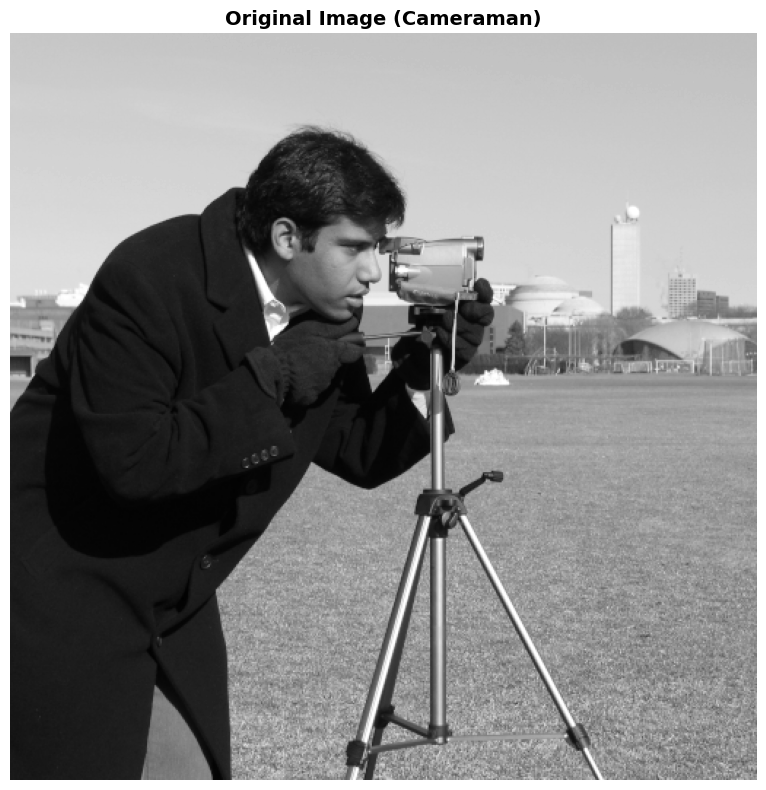

In [2]:
from skimage import data

image = data.camera().astype(np.float64)

print(f"Image shape: {image.shape}")
print(f"Image dtype: {image.dtype}")
print(f"Pixel value range: [{image.min():.0f}, {image.max():.0f}]")
print(f"Total pixels: {image.size:,}")

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(image, cmap='gray')
ax.set_title('Original Image (Cameraman)', fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

## 2. Perform SVD and Analyze Singular Values

The singular value spectrum tells us about the **intrinsic dimensionality** of the image. Rapid decay indicates high compressibility.

In [3]:
U, s, Vt = np.linalg.svd(image, full_matrices=False)

print(f"Number of singular values: {len(s)}")
print(f"Largest singular value (σ₁): {s[0]:.2f}")
print(f"Smallest singular value (σᵣ): {s[-1]:.6f}")
print(f"Condition number (σ₁/σᵣ): {s[0]/s[-1]:.2f}")

# Verify orthogonality of U and V
U_err = np.linalg.norm(U.T @ U - np.eye(U.shape[1]), 'fro')
V_err = np.linalg.norm(Vt @ Vt.T - np.eye(Vt.shape[0]), 'fro')
is_ortho = (U_err < 1e-10) and (V_err < 1e-10)

print(f"\nOrthogonality check:")
print(f"  ||U^T U - I||_F = {U_err:.2e}")
print(f"  ||V V^T - I||_F = {V_err:.2e}")
print(f"  Matrices are orthonormal: {is_ortho}")

Number of singular values: 512
Largest singular value (σ₁): 70966.03
Smallest singular value (σᵣ): 0.005991
Condition number (σ₁/σᵣ): 11845940.72

Orthogonality check:
  ||U^T U - I||_F = 5.46e-14
  ||V V^T - I||_F = 5.50e-14
  Matrices are orthonormal: True


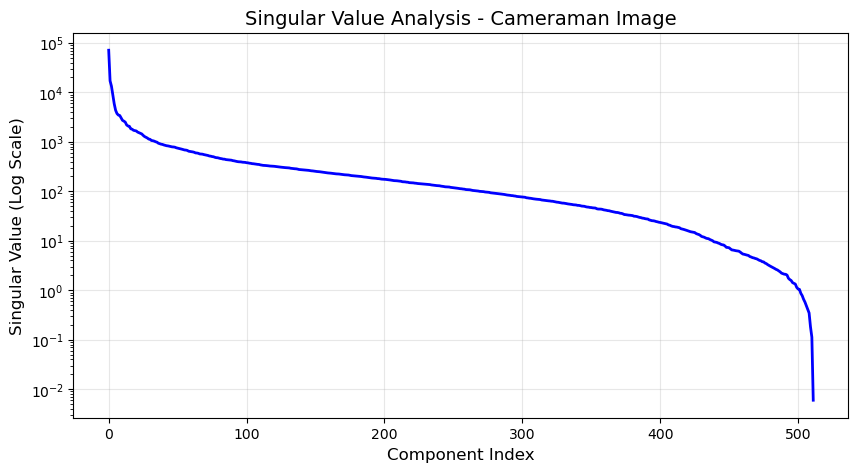


Components needed for variance thresholds:
  90.0% variance: k = 2 (0.4% of total components)
  95.0% variance: k = 3 (0.6% of total components)
  99.0% variance: k = 21 (4.1% of total components)
  99.9% variance: k = 128 (25.0% of total components)


In [4]:
plt.figure(figsize=(10, 5))
plt.plot(s, 'b-', linewidth=2)
plt.yscale('log')
plt.title("Singular Value Analysis - Cameraman Image", fontsize=14)
plt.xlabel("Component Index", fontsize=12)
plt.ylabel("Singular Value (Log Scale)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# Find k values for different variance thresholds
variance = s ** 2
cumulative = np.cumsum(variance) / np.sum(variance)

print("\nComponents needed for variance thresholds:")
for threshold in [0.90, 0.95, 0.99, 0.999]:
    k = np.searchsorted(cumulative, threshold) + 1
    print(f"  {threshold*100:.1f}% variance: k = {k} ({k/len(s)*100:.1f}% of total components)")

## 3. Image Compression with Different Ranks

We'll compress the image using different values of $k$ and visualize the quality-compression tradeoff.

In [5]:
k_values = [5, 10, 20, 50, 100, 200]

reconstructions = []
metrics = []

def comp_ratio(shape, k):
    m, n = shape
    return m * n / (k * (m + n + 1))

print("Compression Results:")
print("-" * 85)
print(f"{'k':>5} | {'Compression':>12} | {'Frobenius Err':>14} | {'Spectral Err':>13} | {'PSNR (dB)':>10}")
print("-" * 85)

for k in k_values:
    svd = TruncatedSVD(n_components=k)
    svd.fit(image)
    
    # Reconstruct the image
    reconstructed = svd.reconstruct()
    
    reconstructed_clipped = np.clip(reconstructed, 0, 255)
    reconstructions.append(reconstructed_clipped)
    
    # Compute metrics
    frob_err = relative_error(image, reconstructed)
    spec_err = np.linalg.norm(image - reconstructed, 2) / np.linalg.norm(image, 2)
    psnr_val = psnr(image, reconstructed_clipped)
    ratio = comp_ratio(image.shape, k)
    
    metrics.append({
        'k': k,
        'frobenius': frob_err,
        'spectral': spec_err,
        'psnr': psnr_val,
        'compression': ratio
    })
    
    print(f"{k:>5} | {ratio:>11.2f}x | {frob_err:>14.4f} | {spec_err:>13.4f} | {psnr_val:>10.2f}")

print("-" * 85)

Compression Results:
-------------------------------------------------------------------------------------
    k |  Compression |  Frobenius Err |  Spectral Err |  PSNR (dB)
-------------------------------------------------------------------------------------
    5 |       51.15x |         0.1720 |        0.0613 |      20.01
   10 |       25.58x |         0.1350 |        0.0383 |      22.11
   20 |       12.79x |         0.1012 |        0.0233 |      24.62
   50 |        5.12x |         0.0636 |        0.0105 |      28.64
  100 |        2.56x |         0.0393 |        0.0053 |      32.82
  200 |        1.28x |         0.0176 |        0.0025 |      39.77
-------------------------------------------------------------------------------------


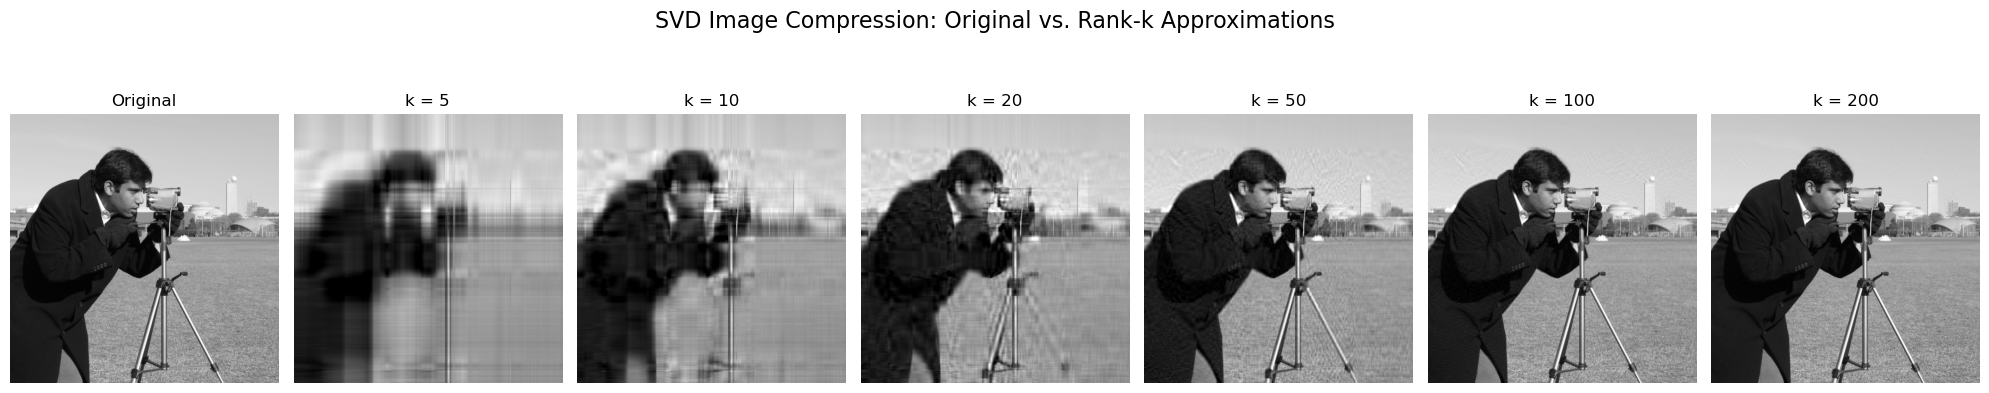

In [6]:
# Visual comparison of reconstructions
fig, axes = plt.subplots(1, len(k_values) + 1, figsize=(20, 4))

axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original', fontsize=12)
axes[0].axis('off')

for i, k in enumerate(k_values):
    axes[i+1].imshow(reconstructions[i], cmap='gray')
    axes[i+1].set_title(f'k = {k}', fontsize=12)
    axes[i+1].axis('off')

fig.suptitle("SVD Image Compression: Original vs. Rank-k Approximations", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

## 4. Eckart-Young-Mirsky Theorem Verification

We'll verify that our computed errors match the theoretical predictions from the theorem:

- **Frobenius**: $\|A - A_k\|_F = \sqrt{\sum_{i=k+1}^{r} \sigma_i^2}$
- **Spectral**: $\|A - A_k\|_2 = \sigma_{k+1}$

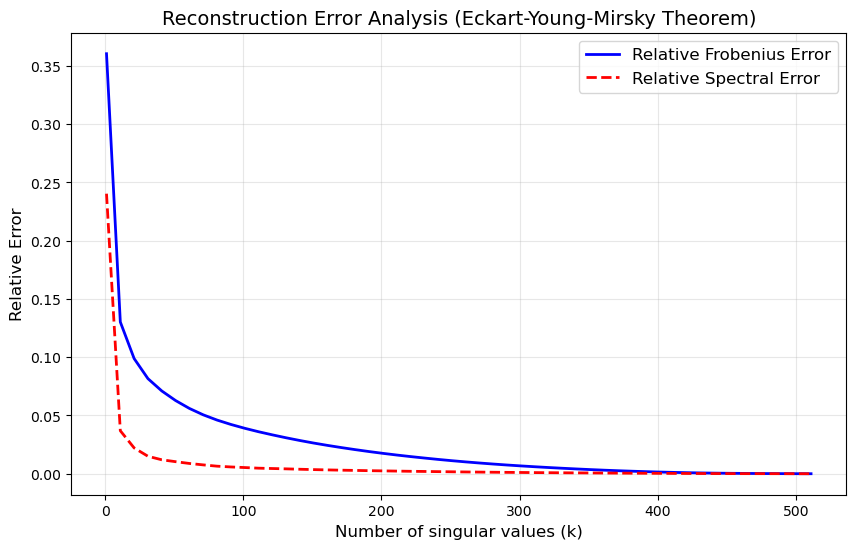

In [7]:
# Evaluate errors across all k values (using a step for efficiency if desired, but here we do all)
all_k = np.arange(1, min(image.shape) + 1, 10) # step by 10 for reasonable execution time
frob_errors = []
spec_errors = []

img_frob_norm = np.linalg.norm(image, 'fro')
img_spec_norm = np.linalg.norm(image, 2)

for k in all_k:
    svd = TruncatedSVD(n_components=k)
    svd.fit(image)
    recon = svd.reconstruct()
    
    frob_errors.append(np.linalg.norm(image - recon, 'fro') / img_frob_norm)
    spec_errors.append(np.linalg.norm(image - recon, 2) / img_spec_norm)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(all_k, frob_errors, 'b-', linewidth=2, label='Relative Frobenius Error')
ax.plot(all_k, spec_errors, 'r--', linewidth=2, label='Relative Spectral Error')

ax.set_xlabel('Number of singular values (k)', fontsize=12)
ax.set_ylabel('Relative Error', fontsize=12)
ax.set_title("Reconstruction Error Analysis (Eckart-Young-Mirsky Theorem)", fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.show()

In [8]:
print("Verification of Eckart-Young-Mirsky Theorem:")
print("=" * 75)
print(f"{'k':>5} | {'Theoretical Frob':>16} | {'Actual Frob':>14} | {'Diff':>12}")
print("-" * 75)

test_k_values = [5, 10, 25, 50, 100, 200]

for k in test_k_values:
    # Theoretical absolute Frobenius error: sqrt(sum(s[k:]**2))
    theoretical = np.sqrt(np.sum(s[k:]**2))
    
    svd = TruncatedSVD(n_components=k)
    svd.fit(image)
    # Actual absolute Frobenius error
    actual = np.linalg.norm(image - svd.reconstruct(), 'fro')
    
    diff = abs(theoretical - actual)
    
    print(f"{k:>5} | {theoretical:>16.6f} | {actual:>14.6f} | {diff:>12.2e}")

print("=" * 75)
print("The small differences confirm the theorem (numerical precision limits)")

Verification of Eckart-Young-Mirsky Theorem:
    k | Theoretical Frob |    Actual Frob |         Diff
---------------------------------------------------------------------------
    5 |     13086.868265 |   13086.868265 |     1.82e-12
   10 |     10272.727229 |   10272.727229 |     1.82e-12
   25 |      6891.484133 |    6891.484133 |     2.73e-12
   50 |      4836.068908 |    4836.068908 |     9.09e-13
  100 |      2992.144382 |    2992.144382 |     4.55e-13
  200 |      1342.358197 |    1342.358197 |     2.27e-13
The small differences confirm the theorem (numerical precision limits)


## 5. Storage Analysis: Compression Efficiency

For a rank-$k$ approximation:
- **Original storage**: $m \times n$ values
- **Compressed storage**: $k(m + n + 1)$ values (for $U_k$, $\Sigma_k$, $V_k^T$)

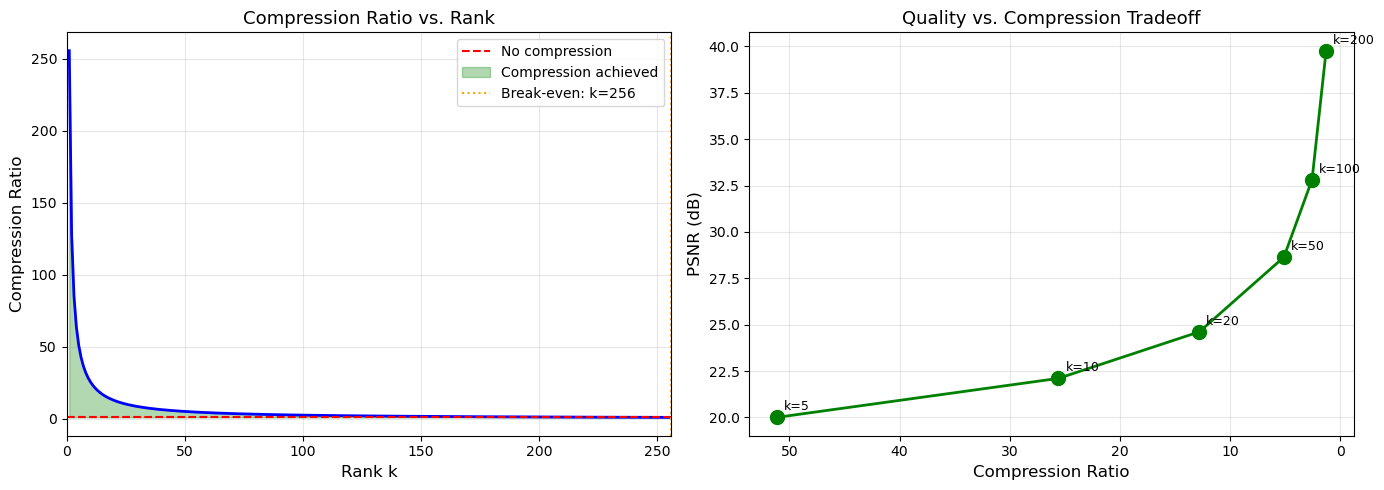


Break-even rank (where compression ratio = 1): k = 256
For k < 256, the SVD representation is actually smaller than the original!


In [9]:
m, n = image.shape
original_storage = m * n

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Compression ratio vs k
k_range = np.arange(1, 257)
comp_ratios = [comp_ratio(image.shape, k) for k in k_range]

ax1 = axes[0]
ax1.plot(k_range, comp_ratios, 'b-', linewidth=2)
ax1.axhline(y=1, color='r', linestyle='--', label='No compression')
ax1.fill_between(k_range, comp_ratios, 1, where=np.array(comp_ratios) > 1, alpha=0.3, color='green', label='Compression achieved')
ax1.set_xlabel('Rank k', fontsize=12)
ax1.set_ylabel('Compression Ratio', fontsize=12)
ax1.set_title('Compression Ratio vs. Rank', fontsize=13)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 256)

break_even_k = m * n / (m + n + 1)
ax1.axvline(x=break_even_k, color='orange', linestyle=':', label=f'Break-even: k={break_even_k:.0f}')
ax1.legend(fontsize=10)

ax2 = axes[1]
metric_k = [m['k'] for m in metrics]
metric_psnr = [m['psnr'] for m in metrics]
metric_comp = [m['compression'] for m in metrics]

ax2.plot(metric_comp, metric_psnr, 'go-', linewidth=2, markersize=10)
for k, comp, p in zip(metric_k, metric_comp, metric_psnr):
    ax2.annotate(f'k={k}', (comp, p), xytext=(5, 5), textcoords='offset points', fontsize=9)

ax2.set_xlabel('Compression Ratio', fontsize=12)
ax2.set_ylabel('PSNR (dB)', fontsize=12)
ax2.set_title('Quality vs. Compression Tradeoff', fontsize=13)
ax2.grid(True, alpha=0.3)
ax2.invert_xaxis()  # Higher compression on the left

plt.tight_layout()
plt.show()

print(f"\nBreak-even rank (where compression ratio = 1): k = {break_even_k:.0f}")
print(f"For k < {break_even_k:.0f}, the SVD representation is actually smaller than the original!")

## 6. Visual Artifact Analysis

Examining compression artifacts helps understand what information is captured at each rank.

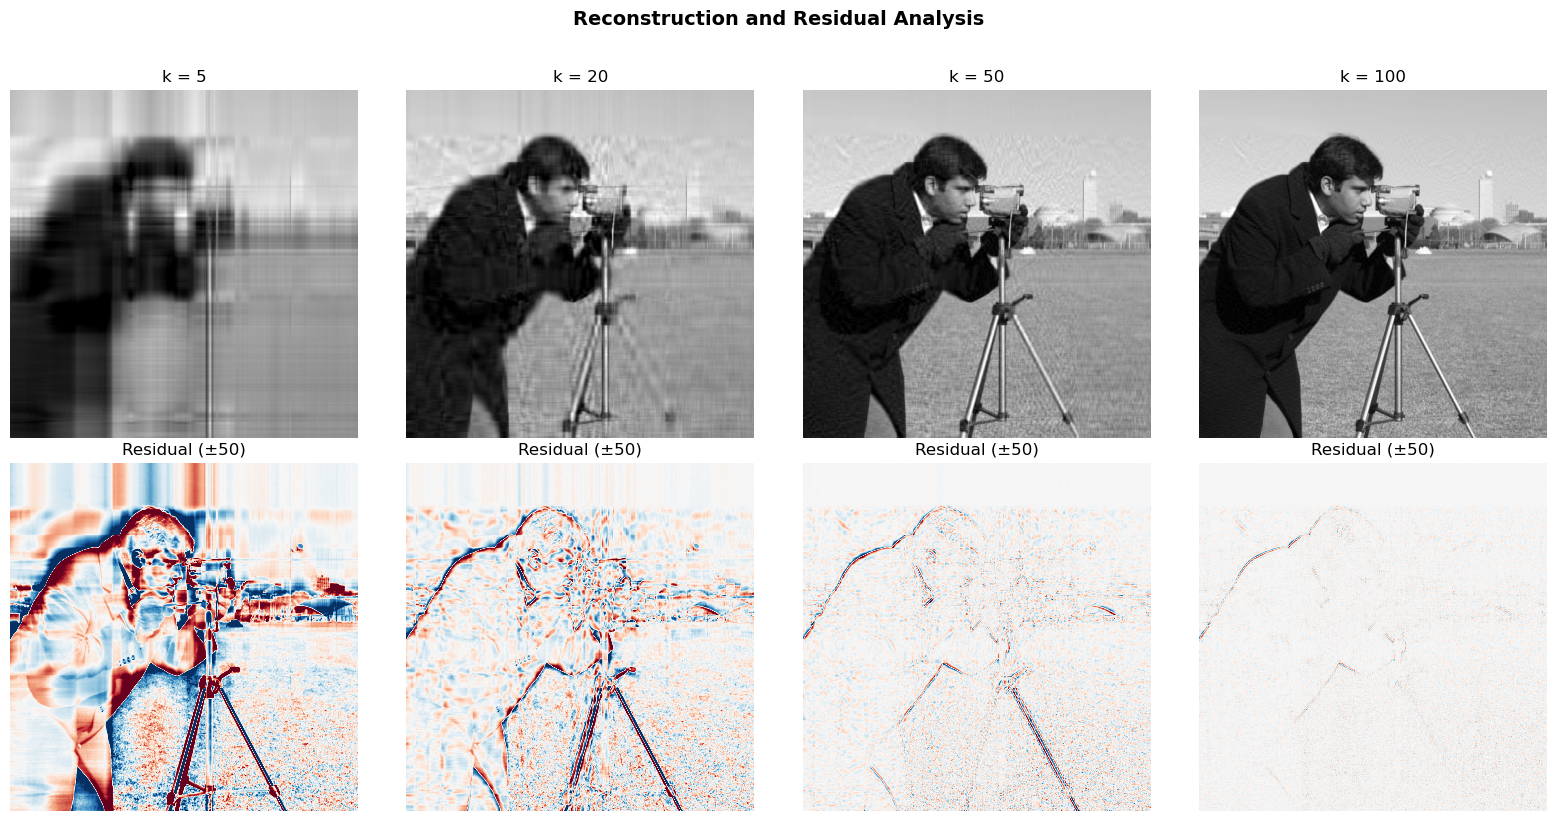

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

selected_k = [5, 20, 50, 100]

for i, k in enumerate(selected_k):
    svd = TruncatedSVD(n_components=k)
    svd.fit(image)
    reconstructed = svd.reconstruct()
    residual = image - reconstructed
    
    axes[0, i].imshow(np.clip(reconstructed, 0, 255), cmap='gray')
    axes[0, i].set_title(f'k = {k}', fontsize=12)
    axes[0, i].axis('off')
    
    axes[1, i].imshow(residual, cmap='RdBu', vmin=-50, vmax=50)
    axes[1, i].set_title(f'Residual (±50)', fontsize=12)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Reconstruction', fontsize=12)
axes[1, 0].set_ylabel('Residual', fontsize=12)

fig.suptitle('Reconstruction and Residual Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Rank-1 Components Visualization

Each singular value corresponds to a rank-1 matrix $\sigma_i u_i v_i^T$. Let's visualize the first few.

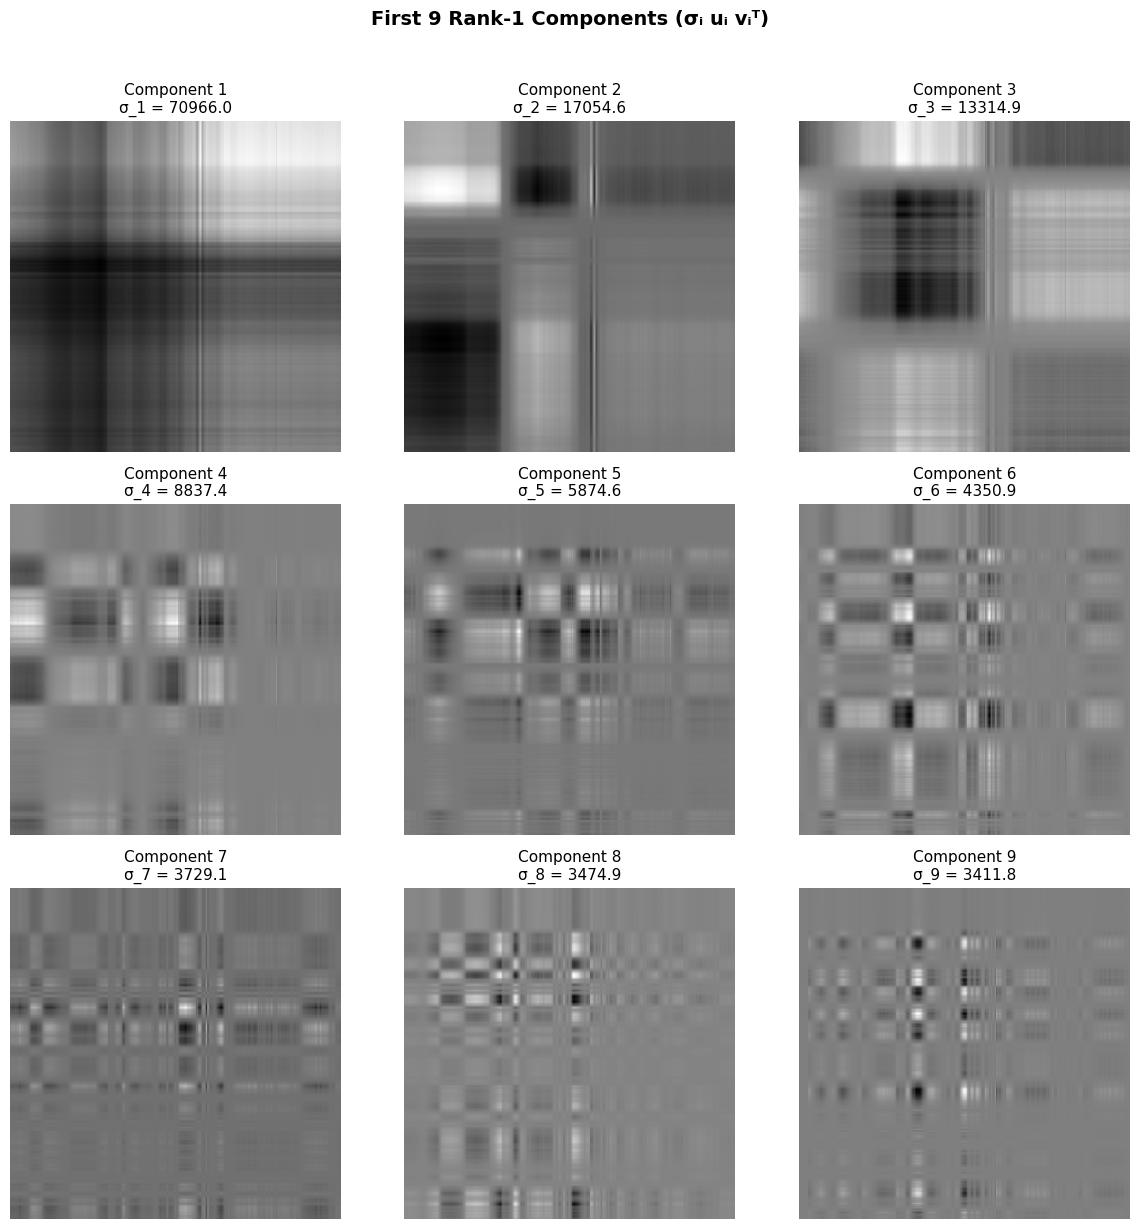

In [11]:
n_components = 9
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for i in range(n_components):
    rank1 = s[i] * np.outer(U[:, i], Vt[i, :])
    
    row, col = i // 3, i % 3
    ax = axes[row, col]
    
    rank1_normalized = (rank1 - rank1.min()) / (rank1.max() - rank1.min()) * 255
    ax.imshow(rank1_normalized, cmap='gray')
    ax.set_title(f'Component {i+1}\nσ_{i+1} = {s[i]:.1f}', fontsize=11)
    ax.axis('off')

fig.suptitle('First 9 Rank-1 Components (σᵢ uᵢ vᵢᵀ)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Summary

### Key Takeaways

1. **SVD provides optimal compression**: The Eckart-Young-Mirsky theorem guarantees that the rank-$k$ approximation is the best possible in both Frobenius and spectral norms.

2. **Singular values indicate compressibility**: Rapid decay of singular values means the image can be well-approximated with few components.

3. **Quality-compression tradeoff**: There's a knee point where adding more components provides diminishing returns.

4. **Artifacts**: Low-rank approximations lose high-frequency details (edges, textures) first.

### Applications
- Image compression
- Noise reduction (keeping only top components)
- Feature extraction for machine learning
- Data visualization (projecting to 2D/3D)